/tmp/ipykernel_683/2413888709.py:11: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(
[*********************100%***********************]  5 of 5 completed


Optimized Portfolio Weights:
   Stock        Weight
0   AAPL  2.864534e-01
1   MSFT  0.000000e+00
2  GOOGL  8.283305e-17
3   AMZN  2.364477e-01
4   TSLA  4.770988e-01

Expected Return: 0.5199489557309972
Portfolio Risk: 0.43344596374675237
Sharpe Ratio: 1.1995704175821684


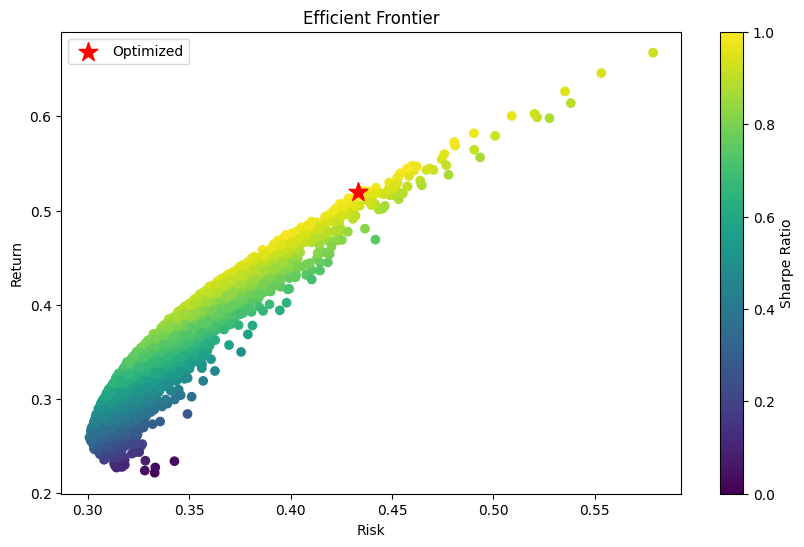

In [2]:
!pip install yfinance scipy
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

stocks = ["AAPL", "MSFT", "GOOGL", "AMZN", "TSLA"]
num_assets = len(stocks)

data = yf.download(
    stocks,
    start="2020-01-01",
    end="2024-01-01"
)["Close"]

returns = data.pct_change().dropna()

# Annualized return
def portfolio_return(weights):
    return np.sum(returns.mean() * weights) * 252

# Annualized volatility
def portfolio_volatility(weights):
    covariance = returns.cov() * 252
    return np.sqrt(np.dot(weights.T, np.dot(covariance, weights)))

# Sharpe Ratio
def sharpe_ratio(weights):
    return portfolio_return(weights) / portfolio_volatility(weights)

constraints = ({
    "type": "eq",
    "fun": lambda x: np.sum(x) - 1
})

bounds = tuple((0, 1) for asset in range(num_assets))

initial_weights = num_assets * [1. / num_assets]

optimized = minimize(
    lambda weights: -sharpe_ratio(weights),
    initial_weights,
    method="SLSQP",
    bounds=bounds,
    constraints=constraints
)

optimal_weights = optimized.x
portfolio = pd.DataFrame({
    "Stock": stocks,
    "Weight": optimal_weights
})

print("Optimized Portfolio Weights:")
print(portfolio)

print("\nExpected Return:", portfolio_return(optimal_weights))
print("Portfolio Risk:", portfolio_volatility(optimal_weights))
print("Sharpe Ratio:", sharpe_ratio(optimal_weights))

# Monte Carlo Simulation
results = []
for i in range(5000):
    weights = np.random.random(num_assets)
    weights /= np.sum(weights)
    ret = portfolio_return(weights)
    vol = portfolio_volatility(weights)
    sharpe = ret / vol
    results.append([ret, vol, sharpe])

results = np.array(results)

plt.figure(figsize=(10,6))
scatter = plt.scatter(
    results[:,1],
    results[:,0],
    c=results[:,2]
)

plt.scatter(portfolio_volatility(optimal_weights), portfolio_return(optimal_weights), color='red', marker='*', s=200, label='Optimized')
plt.xlabel("Risk")
plt.ylabel("Return")

plt.title("Efficient Frontier")
plt.colorbar(label="Sharpe Ratio")
plt.legend()
plt.savefig("efficient_frontier.png")
plt.show()